
GGMM_Variational.ipynb의 같은 추정기·생성식·설정을 사용합니다.
이 파일 하나로 실행합니다. 별도 Python 파일·PKL·자동 저장은 없습니다.
원본 노트북은 수정하지 않았습니다.

보이는 실행 흐름은 표본 준비와 세 실험뿐입니다. 처음 두 정의 셀은 접어서 두어도 됩니다.
1. 기존 참 K=3 표본: max_K=10~15에서 VGGMM과 VGM의 추이.
2. 기존 참 K=10 생성식/표본: max_K=5~15에 VGM 교차 비교 추가.
3. 실험1의 전체 가중치: t=.005/.01/.02의 활성 개수와 제외 질량. 추가 적합 0회.

첫 새 커널에서는 표본 준비 셀이 각 사례의 X를 한 번 생성합니다.
이미 결과가 있는 커널에서는 result/true10_runs/X10를 우선합니다.
노트북에 저장된 표·그림만으로 Python 결과 객체가 복원되는 것은 아닙니다.

실험1은 VGGMM6회+VGM6회입니다. 실험2는 완전한 true10_runs가 있으면 VGM11회만 추가하고,
없으면 VGGMM11회+VGM11회를 수행합니다. 기본 n=5000·두 초기화이므로 계산 시간이 들 수 있습니다.
실험 셀을 필요한 것만 실행하세요. 원본 추정기의 예산을 임의로 줄이지 않았습니다.

active K는 weight>t인 출력 성분 수이며, cap별 ELBO로 최적 cap을 고르지 않습니다.
참 밀도는 IAE/ISE 평가에만 사용합니다. 서로 다른 ELBO 숫자로 모델의 순위를 비교하지 않습니다.
입력·재사용 조건·미수렴·내부 최적화 실패·적분 검사 실패를 표나 메모리 기록에 남깁니다.


In [1]:
"""Independent deterministic variational EM for a truncated DP GGD mixture.

q(v): Beta; q(z): categorical; q(mu): Normal; q(tau): Gamma (shape/rate).
b is a positive point estimate, tau=a**(-b). This is not an exact reproduction
of Amudala's Taylor-approximation algorithm or full Bayes over b.
Only X enters fit. Exported densities are normalized parameter plug-in GGMMs,
not the full posterior predictive density. No BIC search, cache, or file IO.
"""
from dataclasses import dataclass
from time import perf_counter
from typing import cast
import warnings
import numpy as np
from numpy.typing import ArrayLike
from scipy.special import gammaln, digamma, betaln, hyp1f1, logsumexp, xlogy
from scipy.optimize import minimize, brentq
from scipy.stats import gennorm


@dataclass(frozen=True)
class VGGMMConfig:
    max_components: int = 10
    concentration: float = .001
    active_threshold: float = .005
    max_iter: int = 300
    tol: float = 1e-5  # absolute ELBO improvement / n, not LL or gradient tolerance
    inner_max_iter: int = 30
    inner_ftol: float = 1e-8
    mean_prior_sd: float = 3.
    precision_prior_shape: float = 1.
    precision_prior_rate: float = .001
    starts: tuple = ('quantile', 'lloyd')
    fixed_shape: float | None = None


@dataclass(init=False)
class Mixture:
    weights: np.ndarray
    means: np.ndarray
    scales: np.ndarray
    shapes: np.ndarray

    def __init__(self, weights: ArrayLike, means: ArrayLike, scales: ArrayLike, shapes: ArrayLike):
        self.weights = np.asarray(weights, dtype=float).copy()
        self.means = np.asarray(means, dtype=float).copy()
        self.scales = np.asarray(scales, dtype=float).copy()
        self.shapes = np.asarray(shapes, dtype=float).copy()
        if (self.weights.ndim != 1 or not self.weights.size
                or any(getattr(self, k).shape != self.weights.shape
                       for k in ('means', 'scales', 'shapes'))
                or not all(np.isfinite(getattr(self, k)).all()
                           for k in ('weights', 'means', 'scales', 'shapes'))
                or np.any(self.weights < 0) or not np.isclose(self.weights.sum(), 1)
                or np.any(self.scales <= 0) or np.any(self.shapes <= 0)):
            raise ValueError('Invalid mixture parameters.')

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        return self.scales * np.exp(.5*(gammaln(3/self.shapes)-gammaln(1/self.shapes)))

    def component_logpdf(self, x):
        return np.asarray(gennorm.logpdf(np.asarray(x).reshape(-1, 1),
                        self.shapes, loc=self.means, scale=self.scales), dtype=float)

    def logpdf(self, x):
        with np.errstate(divide='ignore'):
            return np.asarray(logsumexp(self.component_logpdf(x)+np.log(self.weights), axis=1), dtype=float)

    def pdf(self, x):
        return np.exp(self.logpdf(x))

    def cdf(self, x):
        return (gennorm.cdf(np.asarray(x).reshape(-1, 1), self.shapes,
                           loc=self.means, scale=self.scales)*self.weights).sum(axis=1)

    def component_ppf(self, p, labels):
        labels = np.asarray(labels, dtype=int)
        return gennorm.ppf(p, self.shapes[labels], loc=self.means[labels], scale=self.scales[labels])

    def formula(self, digits=6):
        f = lambda v: format(float(v), f'.{digits}g')
        return ' + '.join(f'{f(w)} g(x; {f(m)}, {f(a)}, {f(b)})'
            for w, m, a, b in zip(self.weights, self.means, self.scales, self.shapes))

    def payload(self):
        return {k: getattr(self, k).tolist() for k in ('weights','means','scales','shapes')}


def sample_mixture(truth, n, seed):
    # Same vectorized sampling order as GGMM_BIC.ipynb.
    rng = np.random.default_rng(seed)
    labels = rng.choice(truth.k, size=n, p=truth.weights)
    return np.asarray(gennorm.rvs(truth.shapes[labels], loc=truth.means[labels],
                       scale=truth.scales[labels], random_state=rng), dtype=float)


def normal_log_abs_moment(x, mean, log_sd, b):
    """log E|x-U|**b for U~Normal(mean, exp(2*log_sd)), b>0.

    Exact special-function identity, not Taylor expansion or Monte Carlo.
    Unrepresentable proposals are rejected, not exponent/shape clipped.
    """
    with np.errstate(over='raise', invalid='raise', divide='raise', under='ignore'):
        if not np.isfinite(b) or b <= 0 or not np.isfinite(log_sd):
            raise FloatingPointError('Invalid shape or posterior location SD.')
        sd = np.exp(log_sd)
        if sd == 0:
            raise FloatingPointError('Posterior location SD underflow.')
        z = -.5*((np.asarray(x)-mean)/sd)**2
        h = hyp1f1(-b/2, .5, z)
        if np.any(h <= 0) or not np.isfinite(h).all():
            raise FloatingPointError('Normal absolute moment cannot be represented.')
        answer = b*log_sd + b*.5*np.log(2.) + gammaln((b+1)/2)-.5*np.log(np.pi)+np.log(h)
    if not np.isfinite(answer).all():
        raise FloatingPointError('Nonfinite normal absolute moment.')
    return answer


def normal_kl(mean, log_sd, prior_sd):
    with np.errstate(over='raise', invalid='raise', under='ignore'):
        return .5*((np.exp(2*log_sd)+mean*mean)/prior_sd**2-1+2*np.log(prior_sd)-2*log_sd)


def component_profile(y, x, r, cfg):
    """Maximized component ELBO over Gamma q(tau), holding responsibilities fixed.

    y=(mean, log location-posterior SD, log b); b omitted when fixed_shape given.
    Profile objective avoids a slow extra q(tau)-vs-b alternating loop.
    """
    with np.errstate(over='raise', invalid='raise', divide='raise', under='ignore'):
        m, ls = float(y[0]), float(y[1])
        b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else float(np.exp(y[2]))
        lm = normal_log_abs_moment(x, m, ls, b)
        nk = float(r.sum())
        log_r = np.full_like(r, -np.inf)
        np.log(r, out=log_r, where=r > 0)
        log_s = float(np.asarray(logsumexp(log_r+lm)))
        a0, rate0 = cfg.precision_prior_shape, cfg.precision_prior_rate
        a = a0+nk/b
        lb = float(np.logaddexp(np.log(rate0), log_s))
        value = (nk*(-np.log(2.)-gammaln(1+1/b))
                 +gammaln(a)-gammaln(a0)+a0*np.log(rate0)-a*lb
                 -normal_kl(m, ls, cfg.mean_prior_sd))
    if not np.isfinite(value) or not np.isfinite(a):
        raise FloatingPointError('Nonfinite profiled ELBO.')
    return float(value), float(a), lb, b


def stick_posterior(nk, alpha):
    nk = np.asarray(nk, dtype=float)
    return 1+nk[:-1], alpha+np.cumsum(nk[::-1])[::-1][1:]


def stick_statistics(a, b):
    if len(a) == 0:
        return np.ones(1), np.zeros(1)
    elogv = digamma(a)-digamma(a+b)
    elog1v = digamma(b)-digamma(a+b)
    elogw = np.r_[elogv, 0.] + np.r_[0., np.cumsum(elog1v)]
    log_residual = np.log(b)-np.log(a+b)
    logw = np.r_[np.log(a)-np.log(a+b), 0.] + np.r_[0., np.cumsum(log_residual)]
    w = np.exp(logw)
    return w/w.sum(), elogw


def stick_kl(a, b, alpha):
    return float(np.sum(betaln(1., alpha)-betaln(a,b)+(a-1)*digamma(a)
                 +(b-alpha)*digamma(b)-(a+b-1-alpha)*digamma(a+b)))


def gamma_kl(a, log_rate, a0, rate0):
    return ((a-a0)*digamma(a)-gammaln(a)+gammaln(a0)
            +a0*(log_rate-np.log(rate0))-a+rate0*a*np.exp(-log_rate))


def expected_log_components(x, y, gamma_a, gamma_log_rate, cfg):
    out = np.empty((len(x), len(y)))
    for k, row in enumerate(y):
        b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else float(np.exp(row[2]))
        lm = normal_log_abs_moment(x, row[0], row[1], b)
        with np.errstate(over='ignore', invalid='raise'):
            out[:, k] = (-np.log(2.)-gammaln(1+1/b)
                +(digamma(gamma_a[k])-gamma_log_rate[k])/b
                -np.exp(np.log(gamma_a[k])-gamma_log_rate[k]+lm))
    return out


def elbo_value(r, expected_logpdf, sa, sb, y, ga, glb, cfg):
    _, elogw = stick_statistics(sa,sb)
    term = np.zeros_like(r)
    np.multiply(r, expected_logpdf+elogw, out=term, where=r > 0)
    value = term.sum()-xlogy(r,r).sum()-stick_kl(sa,sb,cfg.concentration)
    value -= sum(normal_kl(row[0],row[1],cfg.mean_prior_sd) for row in y)
    value -= gamma_kl(ga,glb,cfg.precision_prior_shape,cfg.precision_prior_rate).sum()
    return float(value)


def _initial_shape(group):
    sd = float(np.std(group))
    ratio = float(np.mean(np.abs(group-group.mean()))/sd) if sd > 0 else np.nan
    if len(group) < 4 or not 0 < ratio < np.sqrt(3)/2:
        return 2.
    def f(eta):
        q = np.exp(-eta)
        return .5*np.log(3)-np.log(2)+gammaln(1+2*q)-.5*(gammaln(1+q)+gammaln(1+3*q))-np.log(ratio)
    lo, hi = -1., 1.
    while f(lo) > 0 and lo > -16: lo -= 1
    while f(hi) < 0 and hi < 24: hi += 1
    return float(np.exp(cast(float,brentq(f,lo,hi)))) if f(lo)*f(hi) <= 0 else 2.


def _partition(x, t, method):
    if method == 'quantile':
        return np.minimum(np.arange(len(x))*t//len(x), t-1)
    if method != 'lloyd':
        raise ValueError('Unknown deterministic initialization.')
    centers = np.quantile(x,(np.arange(t)+.5)/t)
    labels = np.zeros(len(x),dtype=int)
    old = None
    for _ in range(100):
        distances = (x[:,None]-centers)**2
        labels = distances.argmin(axis=1)
        counts = np.bincount(labels,minlength=t)
        for j in np.flatnonzero(counts == 0):
            residual = distances[np.arange(len(x)),labels].copy()
            residual[counts[labels] <= 1] = -np.inf
            index = int(np.argmax(residual))
            counts[labels[index]] -= 1
            labels[index] = j
            counts[j] += 1
        if old is not None and np.array_equal(labels,old): break
        centers = np.array([x[labels == j].mean() for j in range(t)])
        old = labels.copy()
    # Stable initial order only. Never reorder sticks inside the fit.
    order = np.argsort(centers,kind='stable')
    inverse = np.empty(t,int)
    inverse[order] = np.arange(t)
    return inverse[labels]


class VariationalGGMM:
    def __init__(self, config=None):
        self.config = config or VGGMMConfig()

    def _one_start(self, x, t, name):
        cfg = self.config
        begin = perf_counter()
        timings = dict(initialization_s=0.,variational_s=0.,component_updates_s=0.,other_s=0.)
        labels = _partition(x,t,name)
        r = np.eye(t)[labels]
        y = np.zeros((t,2 if cfg.fixed_shape is not None else 3))
        ga, glb = np.empty(t), np.empty(t)
        fallbacks = 0
        for k in range(t):
            group = x[labels == k]
            sd = max(float(group.std()), np.sqrt(np.finfo(float).eps))
            b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else _initial_shape(group)
            y[k,:2] = [group.mean(), np.log(sd/np.sqrt(max(1,len(group))))]
            if cfg.fixed_shape is None: y[k,2] = np.log(b)
            try: _,ga[k],glb[k],_ = component_profile(y[k],x,r[:,k],cfg)
            except (FloatingPointError,ValueError):
                if cfg.fixed_shape is not None: raise
                y[k,2] = np.log(2.)
                fallbacks += 1
                _,ga[k],glb[k],_ = component_profile(y[k],x,r[:,k],cfg)
        sa,sb = stick_posterior(r.sum(axis=0),cfg.concentration)
        init_model = self._density(y,ga,glb,sa,sb)
        timings['initialization_s'] = perf_counter()-begin
        history, whistory = [], []
        rejected, failures, nfev = 0, 0, 0
        reason, converged = 'outer_max_iter',False
        previous = None
        stable = 0
        for iteration in range(cfg.max_iter+1):
            tick = perf_counter()
            elogpdf = expected_log_components(x,y,ga,glb,cfg)
            weights,elogw = stick_statistics(sa,sb)
            value = elbo_value(r,elogpdf,sa,sb,y,ga,glb,cfg)
            plugin = self._density(y,ga,glb,sa,sb)
            record = dict(iteration=iteration,elbo=value-len(x)*np.log(self.unit_),
                log_likelihood=float(plugin.logpdf(self.raw_x_).sum()),
                active_K=int(np.sum(weights > cfg.active_threshold)),seconds=perf_counter()-begin)
            history.append(record)
            whistory.append(weights.copy())
            timings['variational_s'] += perf_counter()-tick
            if not np.isfinite(value):
                raise FloatingPointError('Nonfinite ELBO.')
            if previous is not None:
                gain = (value-previous)/len(x)
                if gain < -1e-7:
                    reason = 'ELBO_decreased_numerical_failure'
                    break
                stable = stable+1 if abs(gain) < cfg.tol else 0
                if stable >= 3:
                    converged,reason = True,'ELBO_gain_per_observation'
                    break
            if iteration == cfg.max_iter: break
            previous = value
            tick = perf_counter()
            logjoint = elogpdf+elogw
            lognorm = logsumexp(logjoint,axis=1,keepdims=True)
            if not np.isfinite(lognorm).all():
                raise FloatingPointError('All components have nonfinite expected density at an observation.')
            r = np.exp(logjoint-lognorm)
            sa,sb = stick_posterior(r.sum(axis=0),cfg.concentration)
            timings['variational_s'] += perf_counter()-tick
            tick = perf_counter()
            for k in range(t):
                rk = r[:,k]
                nk = float(rk.sum())
                if nk < 1e-12:
                    # Numerical zero mass: q(mu),q(tau) revert to their priors.
                    y[k,:2] = [0.,np.log(cfg.mean_prior_sd)]
                    ga[k],glb[k] = cfg.precision_prior_shape,np.log(cfg.precision_prior_rate)
                    continue
                old_y = y[k].copy()
                old_value,*_ = component_profile(old_y,x,rk,cfg)
                best = [old_value,old_y]
                def objective(params):
                    nonlocal rejected
                    try:
                        v,*_ = component_profile(params,x,rk,cfg)
                        if v > best[0]: best[:] = [v,params.copy()]
                        return -v/max(nk,1.)
                    except (FloatingPointError,ValueError,OverflowError):
                        rejected += 1
                        return 1e100
                opt = minimize(objective,old_y,method='L-BFGS-B',
                    options=dict(maxiter=cfg.inner_max_iter,ftol=cfg.inner_ftol,maxls=30))
                failures += int(not opt.success)
                nfev += int(opt.nfev)
                y[k] = best[1]
                _,ga[k],glb[k],_ = component_profile(y[k],x,rk,cfg)
            timings['component_updates_s'] += perf_counter()-tick
        timings['other_s'] = max(0.,perf_counter()-begin-sum(timings.values()))
        return dict(name=name,y=y,ga=ga,glb=glb,sa=sa,sb=sb,history=history,
            weights_history=whistory,converged=converged,reason=reason,
            seconds=perf_counter()-begin,timing=timings,initial=init_model,
            numerical_rejections=rejected,inner_nonconverged=failures,nfev=nfev,
            initial_shape_fallbacks=fallbacks)

    def _density(self,y,ga,glb,sa,sb):
        b = np.full(len(y),self.config.fixed_shape) if self.config.fixed_shape is not None else np.exp(y[:,2])
        a = np.exp((glb-np.log(ga))/b)*self.unit_
        w,_ = stick_statistics(sa,sb)
        return Mixture(w,y[:,0]*self.unit_+self.center_,a,b)

    def fit(self,X):
        cfg = self.config
        self.__dict__ = {'config':cfg,'fit_status_':'running'}
        try:
            return self._fit(X)
        except Exception:
            self.__dict__ = {'config':cfg,'fit_status_':'failed'}
            raise

    def _fit(self,X):
        cfg = self.config
        started = perf_counter()
        x = np.asarray(X,dtype=float)
        if x.ndim == 2 and x.shape[1] == 1: x=x[:,0]
        if x.ndim != 1 or len(x) < 2 or not np.isfinite(x).all() or np.std(x) <= 0:
            raise ValueError('X must contain at least two finite, nonconstant observations.')
        if (any(not isinstance(v,(int,np.integer)) or isinstance(v,(bool,np.bool_)) or v < 1
                for v in [cfg.max_components,cfg.max_iter,cfg.inner_max_iter]) or not cfg.starts
            or any(v not in ('quantile','lloyd') for v in cfg.starts)
            or not 0 <= cfg.active_threshold < 1
            or any(not np.isfinite(v) or v <= 0 for v in [cfg.concentration,cfg.tol,
                cfg.mean_prior_sd,cfg.precision_prior_shape,cfg.precision_prior_rate,cfg.inner_ftol])
            or (cfg.fixed_shape is not None and (not np.isfinite(cfg.fixed_shape) or cfg.fixed_shape <= 0))):
            raise ValueError('Invalid variational configuration.')
        self.center_, self.unit_ = float(x.mean()),float(x.std())
        self.raw_x_ = x.copy()
        z = np.sort((x-self.center_)/self.unit_)
        t = min(cfg.max_components,len(np.unique(x)),len(x))
        runs,failed = [],[]
        for name in cfg.starts:
            try: runs.append(self._one_start(z,t,name))
            except (FloatingPointError,ValueError,OverflowError) as exc:
                failed.append(dict(start=name,error=str(exc)))
        if not runs:
            self.fit_status_ = 'failed'
            raise RuntimeError(f'All variational starts failed: {failed}')
        best = max(runs,key=lambda run:run['history'][-1]['elbo'])
        self.full_density_ = self._density(best['y'],best['ga'],best['glb'],best['sa'],best['sb'])
        self.weights_ = self.full_density_.weights.copy()
        self.active_mask_ = self.weights_ > cfg.active_threshold
        fallback_active = not self.active_mask_.any()
        if fallback_active: self.active_mask_[int(np.argmax(self.weights_))] = True
        keep = self.active_mask_
        self.density_ = Mixture(self.weights_[keep]/self.weights_[keep].sum(),
            self.full_density_.means[keep],self.full_density_.scales[keep],self.full_density_.shapes[keep])
        self.n_components_,self.full_k_ = int(keep.sum()),t
        self.history_,self.weights_history_ = best['history'],best['weights_history']
        self.converged_,self.termination_reason_ = best['converged'],best['reason']
        self.starts_ = [dict(start=run['name'],ELBO=run['history'][-1]['elbo'],
            converged=run['converged'],iterations=run['history'][-1]['iteration'],
            seconds=run['seconds'],chosen=run is best,
            initial_means=run['initial'].means.tolist(),initial_scales=run['initial'].scales.tolist(),
            initial_shapes=run['initial'].shapes.tolist(),initial_weights=run['initial'].weights.tolist(),
            reason=run['reason']) for run in runs]
        self.timing_: dict[str,float] = {key:float(sum(run['timing'][key] for run in runs))
                                       for key in best['timing']}
        self.diagnostics_ = dict(requested_cap=cfg.max_components,used_cap=t,
            inactive_mass=float(self.weights_[~keep].sum()),active_threshold=cfg.active_threshold,
            active_fallback=fallback_active,cap_fully_active=bool(keep.all()),
            last_stick_weight=float(self.weights_[-1]),min_a=float(self.full_density_.scales.min()),
            max_b=float(self.full_density_.shapes.max()),failed_starts=failed,
            numerical_rejections=sum(run['numerical_rejections'] for run in runs),
            inner_nonconverged=sum(run['inner_nonconverged'] for run in runs),
            optimizer_function_evaluations=sum(run['nfev'] for run in runs),
            initial_shape_fallbacks=sum(run['initial_shape_fallbacks'] for run in runs),
            posterior_location_sd=(np.exp(best['y'][:,1])*self.unit_).tolist(),
            gamma_shape=best['ga'].tolist(),gamma_log_rate=best['glb'].tolist(),
            density_kind='posterior-parameter plug-in GGMM; not full posterior predictive',
            inference='q(v) Beta, q(z) categorical, q(mu) Normal, q(tau) Gamma; b point estimate',
            termination_reason=best['reason'])
        self.fit_seconds_ = perf_counter()-started
        # Include failed starts and fit-wrapper overhead in the measured total.
        self.timing_['other_s'] += max(0.,self.fit_seconds_-sum(self.timing_.values()))
        self.fit_status_ = 'completed' if self.converged_ else 'not_converged'
        if not self.converged_:
            warnings.warn('Variational fit did not satisfy the outer convergence criterion: '+best['reason'],RuntimeWarning)
        if failed: warnings.warn(f'{len(failed)} variational initialization(s) failed; see diagnostics_.',RuntimeWarning)
        return self


In [2]:
from dataclasses import asdict, replace

from datetime import datetime, timezone

from importlib.metadata import version as package_version

from time import perf_counter

from typing import Any

import platform

import warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable

from IPython.display import display

from numpy.polynomial.legendre import leggauss

from scipy.special import gammaln

from scipy.integrate import trapezoid

from scipy.stats import gaussian_kde

from sklearn.mixture import BayesianGaussianMixture

from threadpoolctl import threadpool_limits

def _snapshot(model):
    return None if model is None else Mixture(
        weights=np.array(model.weights, copy=True), means=np.array(model.means, copy=True),
        scales=np.array(model.scales, copy=True), shapes=np.array(model.shapes, copy=True))

def run_variational_experiment(x, *, config=None, truth=None, sample_seed=None) -> dict[str, Any]:
    """Every call fits a NEW estimator to X. No fitted model or truth enters fit."""
    observed = np.array(x, dtype=float, copy=True)
    if observed.ndim == 2 and observed.shape[1] == 1:
        observed = observed[:, 0].copy()
    if observed.ndim != 1:
        raise ValueError('X는 하나의 연속형 열인 1차원 배열이어야 합니다.')
    cfg = config or VGGMMConfig()
    model = VariationalGGMM(cfg)
    tick = perf_counter()
    with threadpool_limits(limits=1):
        model.fit(observed)
    seconds = perf_counter()-tick
    observed.setflags(write=False)
    return dict(run_id=datetime.now(timezone.utc).isoformat(timespec='microseconds'),
                x=observed, truth=_snapshot(truth), ggmm=model, config=asdict(cfg),
                fit_seconds=seconds, sample_seed=sample_seed,
                versions=dict(python=platform.python_version(),
                    **{name: package_version(name) for name in
                       ['numpy', 'scipy', 'pandas', 'matplotlib', 'scikit-learn']}))

def show_table(table):
    with pd.option_context('display.max_columns', None, 'display.max_rows', 100,
                           'display.float_format', '{:.6g}'.format):
        display(table)

def _points(model, tail=1e-9):
    probabilities = [tail, 1e-7, 1e-5, .001, .01, .05, .1, .25, .5, .75,
                     .9, .95, .99, .999, 1-1e-5, 1-1e-7, 1-tail]
    p = np.tile(probabilities, model.k)
    labels = np.repeat(np.arange(model.k), len(probabilities))
    return np.unique(np.r_[model.component_ppf(p, labels), model.means,
                           model.means-model.scales, model.means+model.scales])

def density_errors(truth, fitted, tail=1e-9, atol=1e-7, rtol=1e-5):
    """Adaptive mixture IAE/ISE; estimated quadrature errors and tail bounds."""
    if truth is None:
        return dict(IAE=np.nan, ISE=np.nan, Integral_OK=None)
    points = np.unique(np.r_[_points(truth, tail), _points(fitted, tail)])
    if not np.isfinite(points).all():
        raise FloatingPointError('평가 분위수를 수치로 표현할 수 없습니다.')
    left, right = points[:-1], points[1:]
    n_panels = len(left)
    depth = np.zeros(n_panels, int)
    total, error = np.zeros(2), np.zeros(2)
    unresolved = 0
    def panel(l, r, order):
        nodes, weights = leggauss(order)
        mid, half = l/2+r/2, (r-l)/2
        xx = mid[:, None]+half[:, None]*nodes
        delta = (fitted.pdf(xx.ravel())-truth.pdf(xx.ravel())).reshape(xx.shape)
        return np.c_[np.abs(delta)@weights, delta**2@weights]*half[:, None]
    while len(left):
        low, high = panel(left, right, 32), panel(left, right, 64)
        err = np.abs(high-low)
        good = np.all(err <= atol/n_panels/(2.**depth[:, None])+rtol*np.abs(high), axis=1)
        stopped = depth >= 12
        accept = good | stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped & ~good))
        ll, rr, dd = left[~accept], right[~accept], depth[~accept]
        mid = ll/2+rr/2
        left, right, depth = np.r_[ll, mid], np.r_[mid, rr], np.r_[dd+1, dd+1]
    lo, hi = points[0], points[-1]
    def omitted(model):
        return float(np.clip(model.cdf([lo])[0]+1-model.cdf([hi])[0], 0, 1))
    def peak(model):
        return float(np.sum(model.weights*np.exp(-np.log(2)-np.log(model.scales)
                                                -gammaln(1+1/model.shapes))))
    tt, tf = omitted(truth), omitted(fitted)
    return dict(IAE=float(total[0]), ISE=float(total[1]),
                IAE_quad_error=float(error[0]), ISE_quad_error=float(error[1]),
                IAE_tail_upper=tt+tf, ISE_tail_upper=peak(truth)*tt+peak(fitted)*tf,
                Integral_OK=bool(unresolved == 0 and np.all(error <= atol+rtol*np.abs(total))),
                left=float(lo), right=float(hi))

def plot_grid(result, models):
    # Display window is fixed by X, so a tiny broad component cannot erase all
    # visible detail. Integral errors are computed separately, outside this grid.
    x = result['x']
    margin = .15*max(float(np.ptp(x)), float(np.std(x)), np.finfo(float).eps)
    lo, hi = float(x.min()-margin), float(x.max()+margin)
    knots = np.concatenate([x, *[_points(m, 1e-4) for m in models if m is not None]])
    knots = knots[np.isfinite(knots) & (knots >= lo) & (knots <= hi)]
    return np.unique(np.r_[np.linspace(lo, hi, 5000), knots])


In [3]:
# 공통 진단 함수: 기존 모형·평가 함수 정의 셀 뒤에 한 번만 실행하세요.
# 적합은 하지 않으며 기존 result·추정기·표본을 바꾸지 않습니다.
required = ("Mixture", "VGGMMConfig", "VariationalGGMM", "density_errors", "_points",
            "plot_grid", "show_table", "run_variational_experiment")
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError("먼저 기존 모형/보고 함수 정의 셀을 실행하세요: " + ", ".join(missing))
"""상한·문턱 진단: 기존 추정기는 변경하지 않고 메모리에서만 비교한다."""
from dataclasses import asdict, replace
from datetime import datetime, timezone
from importlib.metadata import version
from time import perf_counter
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.special import gammaln
from sklearn.mixture import BayesianGaussianMixture
from threadpoolctl import threadpool_limits


def diagnostics_versions():
    return dict(python=platform.python_version(), **{name: version(name)
        for name in ("numpy", "scipy", "pandas", "matplotlib", "scikit-learn")})


def _diagnostic_sample(x):
    x = np.array(x, dtype=float, copy=True)
    if x.ndim == 2 and x.shape[1] == 1:
        x = x[:, 0].copy()
    if x.ndim != 1 or len(x) < 2 or not np.isfinite(x).all() or np.std(x) <= 0:
        raise ValueError("X는 유한하고 상수가 아닌 하나의 연속형 열이어야 합니다.")
    x.setflags(write=False)
    return x


def _diagnostic_config(config):
    data = asdict(config) if isinstance(config, VGGMMConfig) else dict(config)
    if "starts" in data:
        data["starts"] = tuple(data["starts"])
    return VGGMMConfig(**data)


def _diagnostic_snapshot(model):
    return None if model is None else Mixture(model.weights, model.means, model.scales, model.shapes)


def _diagnostic_same_density(a, b):
    if a is None or b is None:
        return a is b
    return all(np.array_equal(getattr(a, name), getattr(b, name))
        for name in ("weights", "means", "scales", "shapes"))


def _diagnostic_view(full, threshold):
    # 제외 전 전체 가중치에서 판정한다. active 밀도를 다시 자르면 안 된다.
    keep = np.asarray(full.weights) > threshold
    retained, removed = float(full.weights[keep].sum()), float(full.weights[~keep].sum())
    active = None if not keep.any() else Mixture(full.weights[keep]/retained,
        full.means[keep], full.scales[keep], full.shapes[keep])
    return active, int(keep.sum()), removed, retained


def _diagnostic_density_errors(truth, fitted, tail=1e-9, atol=1e-7, rtol=1e-5, max_refinement=16):
    """Adaptive mixture IAE/ISE; estimated quadrature errors and tail bounds."""
    if truth is None:
        return dict(IAE=np.nan, ISE=np.nan, Integral_OK=None)
    points = np.unique(np.r_[_points(truth, tail), _points(fitted, tail)])
    if not np.isfinite(points).all():
        raise FloatingPointError('평가 분위수를 수치로 표현할 수 없습니다.')
    left, right = points[:-1], points[1:]
    n_panels = len(left)
    depth = np.zeros(n_panels, int)
    total, error = np.zeros(2), np.zeros(2)
    unresolved = 0
    def panel(l, r, order):
        nodes, weights = leggauss(order)
        mid, half = l/2+r/2, (r-l)/2
        xx = mid[:, None]+half[:, None]*nodes
        delta = (fitted.pdf(xx.ravel())-truth.pdf(xx.ravel())).reshape(xx.shape)
        return np.c_[np.abs(delta)@weights, delta**2@weights]*half[:, None]
    while len(left):
        low, high = panel(left, right, 32), panel(left, right, 64)
        err = np.abs(high-low)
        good = np.all(err <= atol/n_panels/(2.**depth[:, None])+rtol*np.abs(high), axis=1)
        stopped = depth >= max_refinement
        accept = good | stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped & ~good))
        ll, rr, dd = left[~accept], right[~accept], depth[~accept]
        mid = ll/2+rr/2
        left, right, depth = np.r_[ll, mid], np.r_[mid, rr], np.r_[dd+1, dd+1]
    lo, hi = points[0], points[-1]
    def omitted(model):
        return float(np.clip(model.cdf([lo])[0]+1-model.cdf([hi])[0], 0, 1))
    def peak(model):
        return float(np.sum(model.weights*np.exp(-np.log(2)-np.log(model.scales)
                                                -gammaln(1+1/model.shapes))))
    tt, tf = omitted(truth), omitted(fitted)
    return dict(IAE=float(total[0]), ISE=float(total[1]),
                IAE_quad_error=float(error[0]), ISE_quad_error=float(error[1]),
                IAE_tail_upper=tt+tf, ISE_tail_upper=peak(truth)*tt+peak(fitted)*tf,
                Integral_OK=bool(unresolved == 0 and np.all(error <= atol+rtol*np.abs(total))),
                left=float(lo), right=float(hi))


def _diagnostic_evaluate(x, density, truth):
    if density is None:
        return dict(LL_train=np.nan, IAE=np.nan, ISE=np.nan, Integral_OK=None,
                    Evaluation_s=0., Evaluation_status="no_density")
    tick = perf_counter()
    try:
        m = _diagnostic_density_errors(truth, density)
        return dict(LL_train=float(density.logpdf(x).sum()), IAE=m["IAE"], ISE=m["ISE"],
            Integral_OK=m["Integral_OK"], Evaluation_s=perf_counter()-tick,
            Evaluation_status="ok" if m["Integral_OK"] is not False else "integration_check_failed")
    except (ValueError, FloatingPointError, OverflowError) as exc:
        return dict(LL_train=np.nan, IAE=np.nan, ISE=np.nan, Integral_OK=False,
            Evaluation_s=perf_counter()-tick, Evaluation_status=f"{type(exc).__name__}: {exc}")


def _diagnostic_record(run, cfg, source):
    model = run["ggmm"]
    full = _diagnostic_snapshot(model.full_density_)
    active, _, removed, _ = _diagnostic_view(full, cfg.active_threshold)
    chosen = next((item for item in model.starts_ if item.get("chosen")), {})
    return dict(method="VGGMM", max_k=cfg.max_components, used_cap=full.k,
        full_density=full, active_density=active, fit_seconds=float(run["fit_seconds"]),
        converged=bool(model.converged_), iterations=chosen.get("iterations",
            model.history_[-1]["iteration"] if model.history_ else None),
        stop_reason=model.termination_reason_, chosen_start=chosen.get("start", ""),
        inner_nonconverged=model.diagnostics_.get("inner_nonconverged", 0),
        failed_starts=list(model.diagnostics_.get("failed_starts", [])), warnings=[],
        fit_source=source, fit_error="", excluded_mass=removed)


def _diagnostic_fit_vggmm(x, cfg):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        run = run_variational_experiment(x, config=cfg, truth=None)
    record = _diagnostic_record(run, cfg, "new")
    record["warnings"] = [str(item.message) for item in caught]
    return record


def _diagnostic_fit_vgm(x, cap, cfg):
    used = min(cap, len(x), len(np.unique(x)))
    estimator = BayesianGaussianMixture(n_components=used, covariance_type="full",
        weight_concentration_prior_type="dirichlet_process",
        weight_concentration_prior=cfg.concentration, init_params="kmeans", n_init=1,
        max_iter=1500, tol=1e-3, reg_covar=1e-6, random_state=27)
    supplied = x.copy().reshape(-1, 1)
    with threadpool_limits(limits=1), warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        tick = perf_counter()
        estimator.fit(supplied)
        seconds = perf_counter()-tick
    if not np.array_equal(supplied[:, 0], x):
        raise ValueError("VGM이 입력 X를 변경했습니다.")
    full = Mixture(estimator.weights_/estimator.weights_.sum(), estimator.means_[:, 0],
        np.sqrt(2*estimator.covariances_[:, 0, 0]), np.full(used, 2.))
    active, _, removed, _ = _diagnostic_view(full, cfg.active_threshold)
    return dict(method="VGM", max_k=cap, used_cap=used, full_density=full,
        active_density=active, fit_seconds=seconds, converged=bool(estimator.converged_),
        iterations=int(estimator.n_iter_), stop_reason="tolerance" if estimator.converged_ else "iteration_limit",
        chosen_start="kmeans", inner_nonconverged=None, failed_starts=[],
        warnings=[str(item.message) for item in caught], fit_source="new",
        fit_error="", excluded_mass=removed)


def _diagnostic_validate_runs(existing_runs, x, config, truth, seed=None):
    # 모든 재사용 조건을 새 적합 전에 검사한다. 저장된 그림에서 Python 객체를 복원하지 않는다.
    by_cap, versions = {}, diagnostics_versions()
    for run in (() if existing_runs is None else existing_runs):
        if not isinstance(run, dict) or not {"x", "truth", "config", "ggmm", "fit_seconds", "versions"} <= run.keys():
            raise ValueError("기존 결과는 true10_runs의 실제 Python 객체여야 합니다.")
        previous = _diagnostic_config(run["config"])
        cap = previous.max_components
        if cap in by_cap:
            raise ValueError(f"기존 결과에 상한 {cap}이 중복됩니다.")
        if not np.array_equal(_diagnostic_sample(run["x"]), x):
            raise ValueError("기존 결과의 X가 현재 표본과 다릅니다.")
        if asdict(previous) != asdict(replace(config, max_components=cap)):
            raise ValueError("기존 결과의 상한 외 설정이 다릅니다.")
        if not _diagnostic_same_density(run["truth"], truth):
            raise ValueError("기존 결과의 평가용 참 분포가 다릅니다.")
        if seed is not None and run.get("sample_seed") != seed:
            raise ValueError("기존 결과의 표본 시드 기록이 다릅니다.")
        if run["versions"] != versions:
            raise ValueError("기존 결과와 현재 환경의 버전이 다릅니다. 새로 적합하세요.")
        model = run["ggmm"]
        if not isinstance(model, VariationalGGMM) or not hasattr(model, "full_density_"):
            raise ValueError("기존 VGGMM 추정기의 전체 밀도가 없습니다.")
        if asdict(_diagnostic_config(model.config)) != asdict(previous):
            raise ValueError("모델 객체 설정과 기록된 설정이 다릅니다.")
        if hasattr(model, "raw_x_") and not np.array_equal(model.raw_x_, x):
            raise ValueError("기존 모델이 실제로 사용한 X가 다릅니다.")
        if model.full_density_.k != min(cap, len(x), len(np.unique(x))):
            raise ValueError("기존 모델의 보유 슬롯 수가 해당 상한과 맞지 않습니다.")
        if not np.isfinite(run["fit_seconds"]) or run["fit_seconds"] < 0:
            raise ValueError("기존 적합 시간을 확인할 수 없습니다.")
        by_cap[cap] = run
    return by_cap


def run_cap_diagnostic(X, config, caps, *, truth=None, seed=None, existing_runs=None):
    """cap만 바꿔 비교한다. 참 정보는 적합 뒤 평가에만 사용한다."""
    x, cfg, caps = _diagnostic_sample(X), _diagnostic_config(config), tuple(caps)
    if not caps or len(set(caps)) != len(caps) or any(
        isinstance(k, (bool, np.bool_)) or not isinstance(k, (int, np.integer)) or k < 1 for k in caps):
        raise ValueError("상한은 중복 없는 양의 정수 목록이어야 합니다.")
    if not 0 <= cfg.active_threshold < 1 or not np.isfinite(cfg.concentration) or cfg.concentration <= 0:
        raise ValueError("문턱과 concentration 설정을 확인하세요.")
    reusable = _diagnostic_validate_runs(existing_runs, x, cfg, truth, seed)
    records, rows, tick = [], [], perf_counter()
    for cap in caps:
        current = replace(cfg, max_components=int(cap))
        for name in ("VGGMM", "VGM"):
            started = perf_counter()
            try:
                if name == "VGGMM":
                    record = (_diagnostic_record(reusable[cap], current, "reused") if cap in reusable
                              else _diagnostic_fit_vggmm(x, current))
                else:
                    record = _diagnostic_fit_vgm(x, int(cap), current)
            except Exception as exc:
                record = dict(method=name, max_k=int(cap), used_cap=min(cap, len(x), len(np.unique(x))),
                    full_density=None, active_density=None, fit_seconds=perf_counter()-started,
                    converged=False, iterations=None, stop_reason="fit_failed", chosen_start="",
                    inner_nonconverged=None, failed_starts=[], warnings=[], fit_source="new",
                    fit_error=f"{type(exc).__name__}: {exc}", excluded_mass=np.nan)
            records.append(record)
        print(f"max_K={cap}: " + " | ".join(
            f"{r['method']} K={r['active_density'].k if r['active_density'] is not None else 'failed'}, "
            f"{r['fit_seconds']:.1f}s ({r['fit_source']})" for r in records[-2:]), flush=True)
    reference = _diagnostic_snapshot(truth)  # 전체 적합이 끝난 뒤 평가용 참 밀도를 읽는다.
    for r in records:
        density = r["active_density"]
        k = density.k if density is not None else (0 if r["full_density"] is not None else np.nan)
        rows.append(dict(Method=r["method"], Max_K=r["max_k"], Used_cap=r["used_cap"],
            Active_K=k, At_cap=bool(k == r["used_cap"]) if np.isfinite(k) else None,
            Excluded_mass=r["excluded_mass"], Fit_s=r["fit_seconds"],
            New_fit_s=r["fit_seconds"] if r["fit_source"] == "new" else 0.,
            Fit_source=r["fit_source"], Converged=r["converged"], Iterations=r["iterations"],
            Chosen_start=r["chosen_start"], Inner_nonconverged=r["inner_nonconverged"],
            Failed_starts=len(r["failed_starts"]), Warning_count=len(r["warnings"]) if r["fit_source"]=="new" else None,
            Stop_reason=r["stop_reason"], Fit_error=r["fit_error"],
            **_diagnostic_evaluate(x, density, reference)))
    return dict(x=x, truth=reference, config=asdict(cfg), caps=caps, records=records,
        table=pd.DataFrame(rows), versions=diagnostics_versions(), seed=seed,
        threshold=cfg.active_threshold, run_id=datetime.now(timezone.utc).isoformat(),
        total_seconds=perf_counter()-tick)


def show_cap_diagnostic(study, *, density_caps=None):
    """표·추이·밀도 그림을 같은 실험 셀에 함께 표시한다."""
    table = study["table"]
    print(f"n={len(study['x']):,} | seed={study['seed']} | t={study['threshold']:g}")
    print("Fit_s: 원래 적합 시간. New_fit_s: 이번 추가 적합 시간. reused: 재적합 없음.")
    show_table(table[["Method", "Max_K", "Active_K", "Excluded_mass", "IAE", "ISE",
        "Fit_s", "New_fit_s", "Fit_source", "Converged", "Chosen_start", "Inner_nonconverged",
        "Stop_reason", "Integral_OK", "Evaluation_status"]])
    failures = table[table["Fit_error"] != ""]
    if not failures.empty:
        show_table(failures[["Method", "Max_K", "Fit_error"]])
    print("VGGMM 설정:", study["config"])
    print("VGM: alpha=같은concentration, kmeans, n_init=1, seed=27, max_iter=1500, tol=.001, reg_covar=1e-6")
    print("초기화·위치/척도 사전·수렴 기준은 두 구현에서 다릅니다.")
    fig, axes = plt.subplots(2, 2, figsize=(11, 6), layout="constrained")
    for name, color, style in (("VGGMM", "#c43c39", "-"), ("VGM", "#2865b0", "--")):
        data = table[table["Method"] == name]
        for ax, metric in zip(axes.flat, ("Active_K", "IAE", "ISE", "Fit_s")):
            ax.plot(data["Max_K"], data[metric], "o"+style, color=color, label=name)
    fig.suptitle(f"Cap sensitivity: n={len(study['x']):,}, t={study['threshold']:g}")
    axes[0, 0].plot(study["caps"], study["caps"], ":", color="gray", label="K = cap")
    axes[0, 0].legend(fontsize=9)
    for ax, metric in zip(axes.flat, ("Active_K", "IAE", "ISE", "Fit_s")):
        ax.set(xlabel="Maximum components", ylabel=metric, xticks=study["caps"])
        ax.grid(alpha=.2)
    plt.show()
    selected = tuple(study["caps"]) if density_caps is None else tuple(density_caps)
    if not selected or any(cap not in study["caps"] for cap in selected):
        raise ValueError("밀도 그림에는 실행한 상한을 지정하세요.")
    fig, axes = plt.subplots(int(np.ceil(len(selected)/3)), min(3, len(selected)),
        figsize=(14, 3.3*int(np.ceil(len(selected)/3))), squeeze=False, layout="constrained")
    fig.suptitle(f"Same sample: n={len(study['x']):,}; * = not converged")
    reference = study["truth"]
    for ax, cap in zip(axes.flat, selected):
        recs = [r for r in study["records"] if r["max_k"] == cap and r["active_density"] is not None]
        grid = plot_grid(study, [reference, *[r["active_density"] for r in recs]])
        ax.hist(study["x"], bins=70, density=True, color="#dce2e8", edgecolor="white", linewidth=.2)
        if reference is not None:
            ax.plot(grid, reference.pdf(grid), "k:", lw=1.6, label="True density")
        for r in recs:
            density = r["active_density"]
            color, style = ("#c43c39", "-") if r["method"] == "VGGMM" else ("#2865b0", "--")
            ax.plot(grid, density.pdf(grid), color=color, ls=style, lw=1.7,
                label=f"{r['method']} K={density.k}" + ("" if r["converged"] else " *"))
        ax.set(title=f"max_K={cap}", xlabel="x", ylabel="Density")
        ax.legend(fontsize=8)
    for ax in list(axes.flat)[len(selected):]:
        ax.set_visible(False)
    plt.show()
    print("* 표시는 미수렴입니다. 상한별 ELBO로 최적 상한을 고르는 실험이 아닙니다.")
    return table


def threshold_diagnostic(study, thresholds=(.005, .01, .02)):
    """같은 fit의 전체 가중치에서 문턱 영향을 확인한다. 추가 적합은 없다."""
    thresholds = tuple(thresholds)
    if not thresholds or len(set(thresholds)) != len(thresholds) or any(
        not np.isfinite(t) or not 0 <= t < 1 for t in thresholds):
        raise ValueError("문턱은 중복 없이 0 이상 1 미만이어야 합니다.")
    records, rows = [], []
    for parent in study["records"]:
        for threshold in thresholds:
            full = parent["full_density"]
            if full is None:
                density, k, removed, retained, status = None, np.nan, np.nan, np.nan, "fit_failed"
            else:
                density, k, removed, retained = _diagnostic_view(full, threshold)
                status = "ok" if density is not None else "no_active_components"
            rows.append(dict(Method=parent["method"], Max_K=parent["max_k"], Threshold=threshold,
                Active_K=k, Excluded_mass=removed, Retained_mass=retained,
                Additional_fit_s=0., Original_fit_s=parent["fit_seconds"], Converged=parent["converged"],
                Fit_source=parent["fit_source"], Status=status,
                **_diagnostic_evaluate(study["x"], density, study["truth"])))
            records.append(dict(parent=parent, threshold=threshold, density=density))
    return dict(study=study, thresholds=thresholds, records=records, table=pd.DataFrame(rows))


def show_threshold_diagnostic(result):
    table = result["table"]
    show_table(table[["Method", "Max_K", "Threshold", "Active_K", "Excluded_mass",
        "IAE", "ISE", "Converged", "Status", "Additional_fit_s"]])
    fig, axes = plt.subplots(2, 2, figsize=(11, 6), layout="constrained")
    fig.suptitle(f"Post-fit thresholds: n={len(result['study']['x']):,}; no refit")
    colors = ("#3267b0", "#bc4d3b", "#2c8b66", "#775aa6")
    for col, method in enumerate(("VGGMM", "VGM")):
        for j, threshold in enumerate(result["thresholds"]):
            data = table[(table["Method"] == method) & (table["Threshold"] == threshold)]
            for row, metric in enumerate(("Active_K", "Excluded_mass")):
                axes[row, col].plot(data["Max_K"], data[metric], "o-", color=colors[j%len(colors)],
                                    label=f"t={threshold:g}")
        for row, metric in enumerate(("Active_K", "Excluded_mass")):
            axes[row, col].set(title=method, xlabel="Maximum components", ylabel=metric)
            axes[row, col].legend(fontsize=8)
            axes[row, col].grid(alpha=.2)
    plt.show()
    print("추가 적합 0회. 같은 전체 가중치의 판정/출력 민감도이며 삭제 후 재학습이 아닙니다.")
    print("오차나 참 K를 보고 최종 문턱을 고르지 않습니다.")
    return table


In [4]:
# 표본 준비: 새 커널에서는 기존 생성식·시드로 표본을 각 사례당 한 번만 만듭니다.
# 기존 result/true10_runs/X10가 있으면 해당 표본을 우선합니다. cap마다 생성하지 않습니다.
# 이 셀은 적합하지 않으며 기존 result를 덮어쓰지 않습니다.
if isinstance(globals().get("result"), dict) and {"x", "truth", "config"} <= result.keys():
    diagnostic_input = result
else:
    baseline_truth = Mixture([.2,.3,.5], [-5.,0.,6.], [1.2,1.6,2.], [1.5,4.,8.])
    diagnostic_input = dict(
        x=sample_mixture(baseline_truth, 5000, 20260912), truth=baseline_truth,
        config=asdict(VGGMMConfig()), sample_seed=20260912)
if not globals().get("true10_runs") and "X10" not in globals():
    truth10 = Mixture([.06,.08,.10,.12,.14,.14,.12,.10,.08,.06],
        [-18,-14,-10,-6,-2,2,6,10,14,18],
        [1.,1.2,1.4,1.,1.3,1.1,1.5,1.2,1.,1.4],
        [1.2,2.,3.,4.,6.,1.5,2.5,5.,8.,3.5])
    X10_SEED = 20260919
    X10 = sample_mixture(truth10, 5000, X10_SEED)
print("표본 준비 완료. 새 커널의 생성 시드는 기존 코드와 같고, 각 실험 안에서는 X를 고정합니다.")


표본 준비 완료. 새 커널의 생성 시드는 기존 코드와 같고, 각 실험 안에서는 X를 고정합니다.


max_K=10: VGGMM K=10, 177.3s (new) | VGM K=5, 1.0s (new)
max_K=11: VGGMM K=11, 184.6s (new) | VGM K=5, 1.1s (new)
max_K=12: VGGMM K=12, 235.7s (new) | VGM K=5, 1.3s (new)
max_K=13: VGGMM K=13, 169.4s (new) | VGM K=5, 0.8s (new)
max_K=14: VGGMM K=14, 190.0s (new) | VGM K=5, 1.1s (new)
max_K=15: VGGMM K=14, 246.1s (new) | VGM K=5, 1.3s (new)
n=5,000 | seed=20260912 | t=0.005
Fit_s: 원래 적합 시간. New_fit_s: 이번 추가 적합 시간. reused: 재적합 없음.


,Method,Max_K,Active_K,Excluded_mass,IAE,ISE,Fit_s,New_fit_s,Fit_source,Converged,Chosen_start,Inner_nonconverged,Stop_reason,Integral_OK,Evaluation_status
0,VGGMM,10,10,0,0.0538642,0.000338802,177.306,177.306,new,True,quantile,1,ELBO_gain_per_observation,True,ok
1,VGM,10,5,0.00127495,0.108209,0.00125026,0.968219,0.968219,new,True,kmeans,NaN,tolerance,True,ok
2,VGGMM,11,11,0,0.0547438,0.000472354,184.635,184.635,new,True,lloyd,0,ELBO_gain_per_observation,True,ok
3,VGM,11,5,0.00127628,0.108168,0.00124969,1.07809,1.07809,new,True,kmeans,NaN,tolerance,True,ok
4,VGGMM,12,12,0,0.0641679,0.000612166,235.706,235.706,new,True,lloyd,0,ELBO_gain_per_observation,True,ok
5,VGM,12,5,0.00177928,0.10973,0.0012703,1.31992,1.31992,new,True,kmeans,NaN,tolerance,True,ok
6,VGGMM,13,13,0,0.0676488,0.000566611,169.423,169.423,new,True,lloyd,0,ELBO_gain_per_observation,True,ok
7,VGM,13,5,0.00178191,0.108936,0.00125932,0.790349,0.790349,new,True,kmeans,NaN,tolerance,True,ok
8,VGGMM,14,14,0,0.0649355,0.000479029,189.997,189.997,new,True,lloyd,0,ELBO_gain_per_observation,True,ok
9,VGM,14,5,0.00178165,0.108848,0.00125814,1.06627,1.06627,new,True,kmeans,NaN,tolerance,True,ok


VGGMM 설정: {'max_components': 10, 'concentration': 0.001, 'active_threshold': 0.005, 'max_iter': 300, 'tol': 1e-05, 'inner_max_iter': 30, 'inner_ftol': 1e-08, 'mean_prior_sd': 3.0, 'precision_prior_shape': 1.0, 'precision_prior_rate': 0.001, 'starts': ('quantile', 'lloyd'), 'fixed_shape': None}
VGM: alpha=같은concentration, kmeans, n_init=1, seed=27, max_iter=1500, tol=.001, reg_covar=1e-6
초기화·위치/척도 사전·수렴 기준은 두 구현에서 다릅니다.


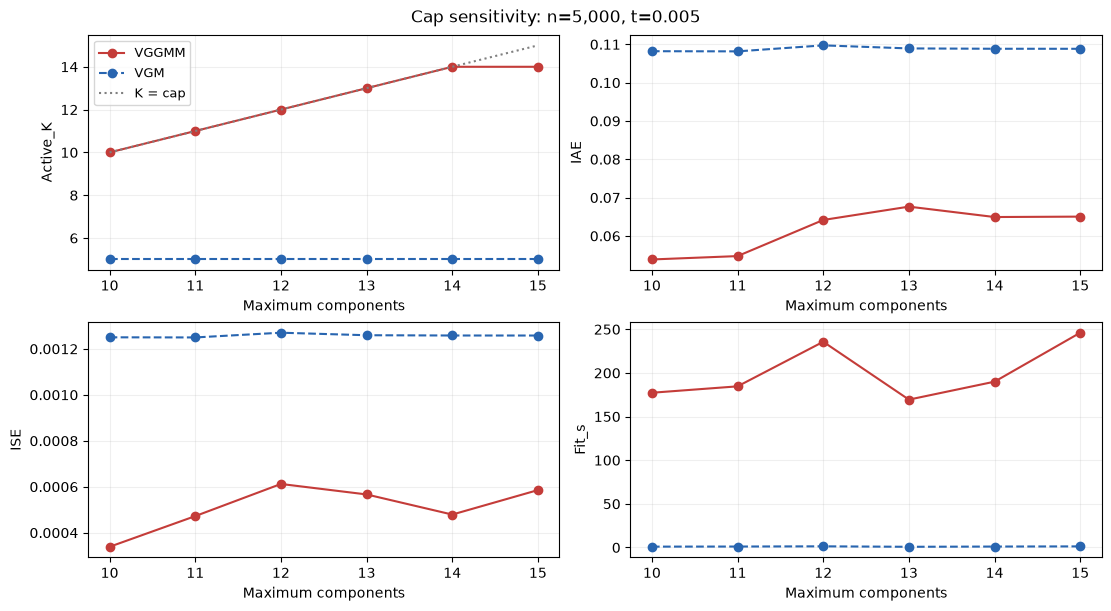

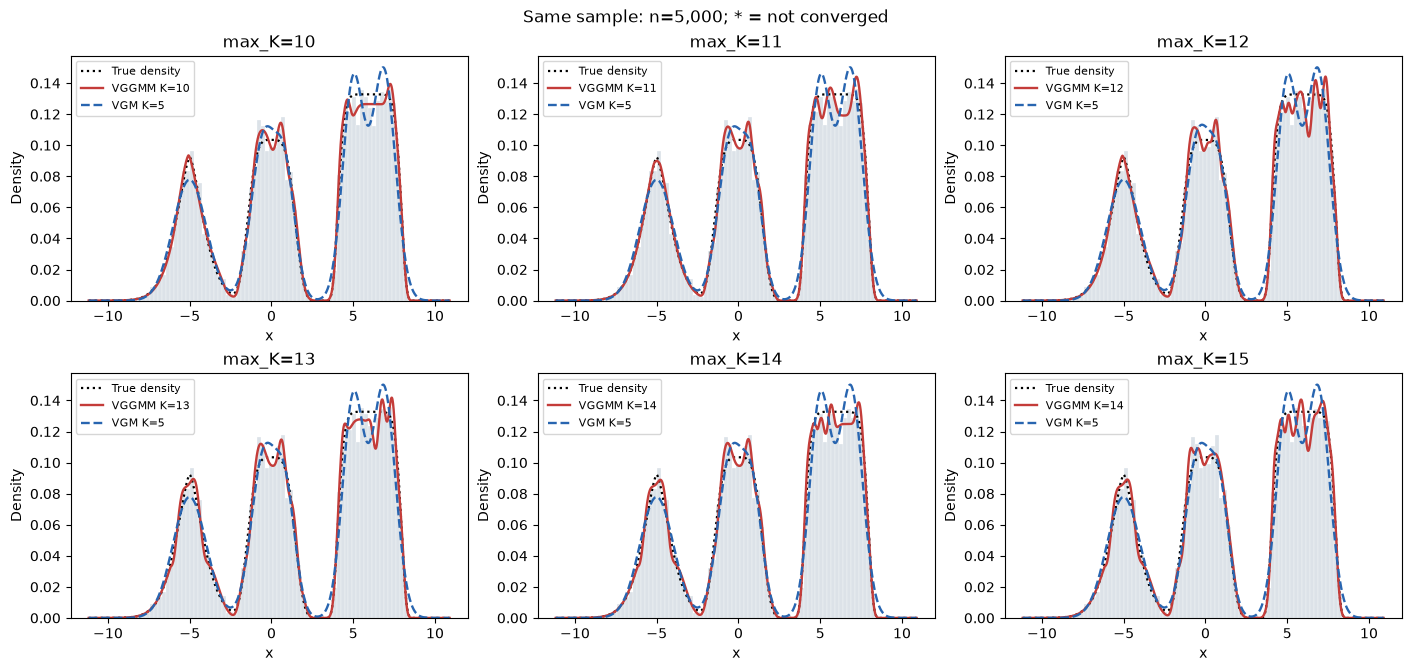

* 표시는 미수렴입니다. 상한별 ELBO로 최적 상한을 고르는 실험이 아닙니다.


In [5]:
# 실험 1: 같은 기존 X에서 max_K=10~15의 활성 K·오차·시간을 비교합니다.
# 각 상한에서 두 모델을 새로 적합합니다. 참 정보는 사후 평가용입니다.
# 기존 result는 유지하며 표·추이·밀도 그림을 이 셀에 함께 표시합니다.
base_input = globals().get("result") or globals().get("diagnostic_input")
if not isinstance(base_input, dict) or not {"x", "truth", "config"} <= base_input.keys():
    raise RuntimeError("기존 result 또는 전용 노트북의 표본 준비 셀을 먼저 실행하세요.")
vggmm_cap10_15 = run_cap_diagnostic(
    base_input["x"], _diagnostic_config(base_input["config"]), range(10, 16),
    truth=base_input["truth"], seed=base_input.get("sample_seed"))
cap10_15_table = show_cap_diagnostic(vggmm_cap10_15)


기존 VGGMM 결과 객체가 없어 두 모델을 새로 적합합니다. X10는 그대로 사용합니다.
max_K=5: VGGMM K=5, 15.5s (new) | VGM K=5, 1.9s (new)
max_K=6: VGGMM K=6, 32.4s (new) | VGM K=6, 0.5s (new)
max_K=7: VGGMM K=7, 35.7s (new) | VGM K=6, 1.5s (new)
max_K=8: VGGMM K=8, 31.8s (new) | VGM K=8, 2.3s (new)
max_K=9: VGGMM K=9, 57.1s (new) | VGM K=9, 0.1s (new)
max_K=10: VGGMM K=10, 83.8s (new) | VGM K=9, 0.7s (new)
max_K=11: VGGMM K=11, 63.0s (new) | VGM K=9, 0.6s (new)
max_K=12: VGGMM K=12, 65.1s (new) | VGM K=9, 0.8s (new)
max_K=13: VGGMM K=13, 97.0s (new) | VGM K=9, 0.4s (new)
max_K=14: VGGMM K=13, 149.5s (new) | VGM K=9, 0.6s (new)
max_K=15: VGGMM K=15, 151.0s (new) | VGM K=9, 0.7s (new)
n=5,000 | seed=20260919 | t=0.005
Fit_s: 원래 적합 시간. New_fit_s: 이번 추가 적합 시간. reused: 재적합 없음.


,Method,Max_K,Active_K,Excluded_mass,IAE,ISE,Fit_s,New_fit_s,Fit_source,Converged,Chosen_start,Inner_nonconverged,Stop_reason,Integral_OK,Evaluation_status
0,VGGMM,5,5,0,0.475695,0.00791573,15.4654,15.4654,new,True,quantile,0,ELBO_gain_per_observation,True,ok
1,VGM,5,5,0,0.618651,0.0124075,1.93594,1.93594,new,True,kmeans,NaN,tolerance,True,ok
2,VGGMM,6,6,0,0.381122,0.00681483,32.3517,32.3517,new,True,quantile,0,ELBO_gain_per_observation,True,ok
3,VGM,6,6,0,0.456717,0.00684542,0.500705,0.500705,new,True,kmeans,NaN,tolerance,True,ok
4,VGGMM,7,7,0,0.319398,0.00518001,35.7348,35.7348,new,True,lloyd,0,ELBO_gain_per_observation,True,ok
5,VGM,7,6,1.9893e-07,0.524607,0.00991219,1.52164,1.52164,new,True,kmeans,NaN,tolerance,True,ok
6,VGGMM,8,8,0,0.190834,0.00239262,31.7882,31.7882,new,True,lloyd,0,ELBO_gain_per_observation,True,ok
7,VGM,8,8,0,0.361623,0.00430489,2.30619,2.30619,new,True,kmeans,NaN,tolerance,True,ok
8,VGGMM,9,9,0,0.190894,0.00239438,57.1277,57.1277,new,True,lloyd,0,ELBO_gain_per_observation,True,ok
9,VGM,9,9,0,0.323726,0.00343797,0.136036,0.136036,new,True,kmeans,NaN,tolerance,True,ok


VGGMM 설정: {'max_components': 10, 'concentration': 0.001, 'active_threshold': 0.005, 'max_iter': 300, 'tol': 1e-05, 'inner_max_iter': 30, 'inner_ftol': 1e-08, 'mean_prior_sd': 3.0, 'precision_prior_shape': 1.0, 'precision_prior_rate': 0.001, 'starts': ('quantile', 'lloyd'), 'fixed_shape': None}
VGM: alpha=같은concentration, kmeans, n_init=1, seed=27, max_iter=1500, tol=.001, reg_covar=1e-6
초기화·위치/척도 사전·수렴 기준은 두 구현에서 다릅니다.


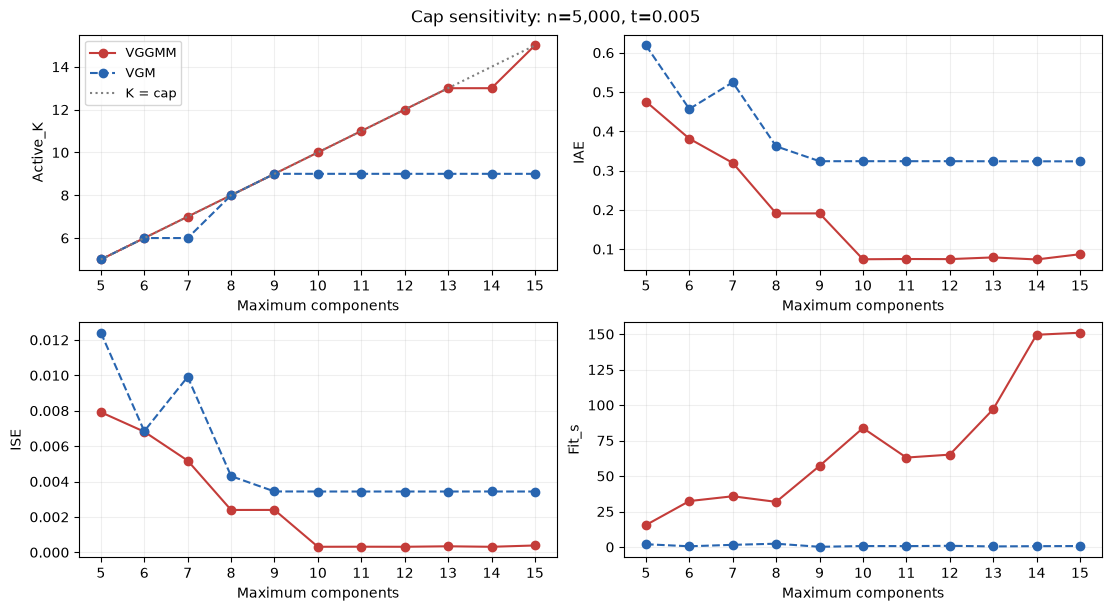

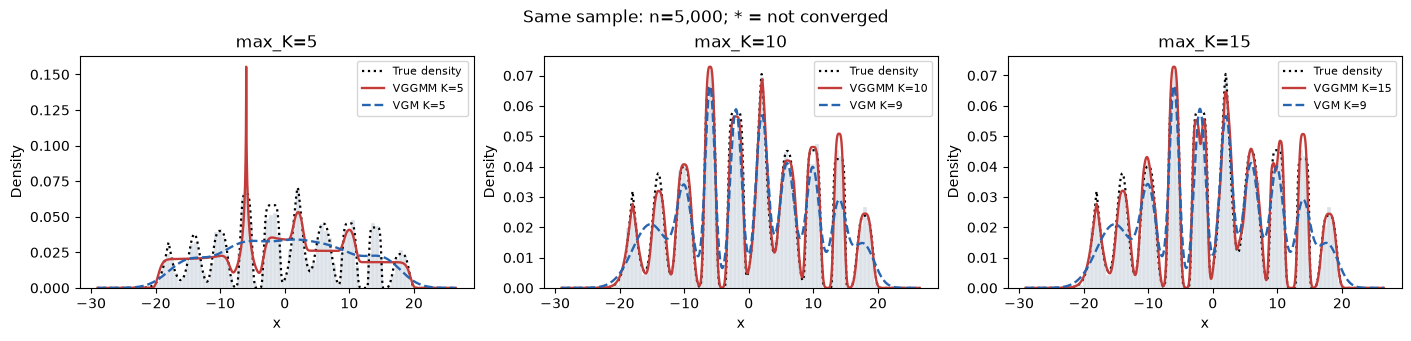

* 표시는 미수렴입니다. 상한별 ELBO로 최적 상한을 고르는 실험이 아닙니다.


In [6]:
# 실험 2: 이미 만든 참 K=10 사례의 상한 5~15 비교에 VGM을 붙입니다.
# true10_runs가 현재 커널에 있으면 조건을 검사한 뒤 VGGMM을 재사용하고 VGM만 적합합니다.
# 기존 객체가 없으면 X10/truth10에서 두 모델을 새로 적합합니다. 이 셀은 표본을 생성하지 않습니다.
previous10 = list(globals().get("true10_runs", []))
if previous10:
    input10 = previous10[0]
    x10_input, truth10_input = input10["x"], input10["truth"]
    config10_input = _diagnostic_config(input10["config"])
    seed10_input = input10.get("sample_seed")
else:
    if "X10" not in globals() or "truth10" not in globals():
        raise RuntimeError("기존 X10/truth10 또는 true10_runs가 필요합니다. 전용 노트북에서는 표본 준비 셀을 실행하세요.")
    base_input = globals().get("result") or globals().get("diagnostic_input")
    if not isinstance(base_input, dict) or "config" not in base_input:
        raise RuntimeError("기존 result 또는 표본 준비 셀의 설정이 필요합니다.")
    x10_input, truth10_input = X10, truth10
    config10_input = _diagnostic_config(base_input["config"])
    seed10_input = globals().get("X10_SEED")
    print("기존 VGGMM 결과 객체가 없어 두 모델을 새로 적합합니다. X10는 그대로 사용합니다.")
vggmm_true10_compare = run_cap_diagnostic(
    x10_input, config10_input, range(5, 16), truth=truth10_input,
    seed=seed10_input, existing_runs=previous10)
true10_comparison_table = show_cap_diagnostic(
    vggmm_true10_compare, density_caps=(5, 10, 15))


,Method,Max_K,Threshold,Active_K,Excluded_mass,IAE,ISE,Converged,Status,Additional_fit_s
0,VGGMM,10,0.005,10,0,0.0538642,0.000338802,True,ok,0
1,VGGMM,10,0.01,10,0,0.0538642,0.000338802,True,ok,0
2,VGGMM,10,0.02,10,0,0.0538642,0.000338802,True,ok,0
3,VGGMM,10,0.05,7,0.0959628,0.116108,0.00199861,True,ok,0
4,VGGMM,10,0.1,5,0.270046,0.227776,0.00662993,True,ok,0
5,VGM,10,0.005,5,0.00127495,0.108209,0.00125026,True,ok,0
6,VGM,10,0.01,5,0.00127495,0.108209,0.00125026,True,ok,0
7,VGM,10,0.02,5,0.00127495,0.108209,0.00125026,True,ok,0
8,VGM,10,0.05,5,0.00127495,0.108209,0.00125026,True,ok,0
9,VGM,10,0.1,5,0.00127495,0.108209,0.00125026,True,ok,0


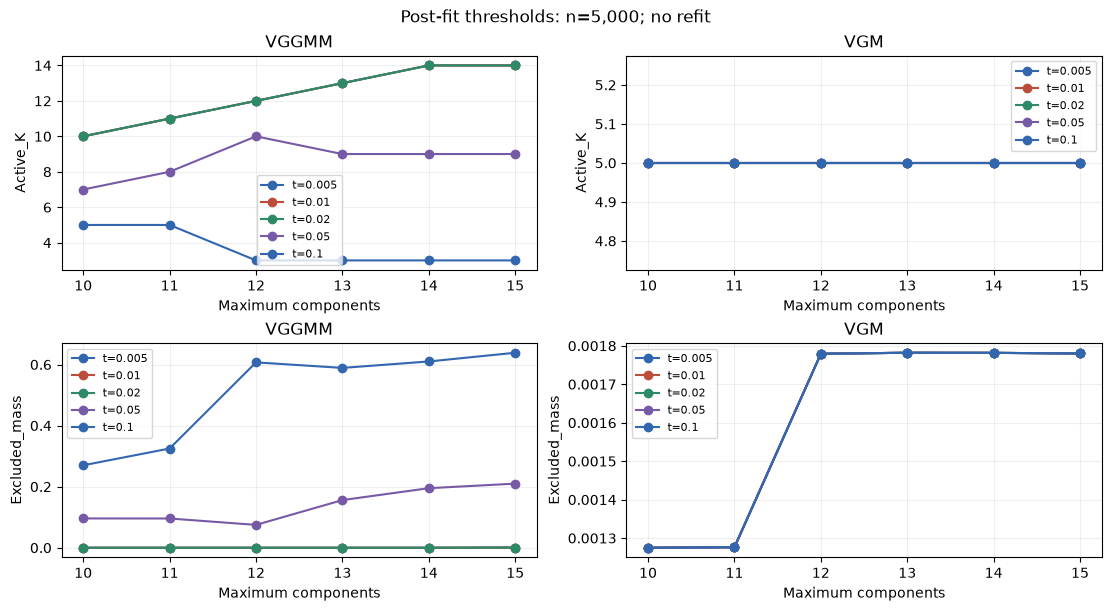

추가 적합 0회. 같은 전체 가중치의 판정/출력 민감도이며 삭제 후 재학습이 아닙니다.
오차나 참 K를 보고 최종 문턱을 고르지 않습니다.


In [8]:
# 실험 3: 실험 1의 같은 전체 가중치에서 t=.005/.01/.02를 비교합니다.
# 재적합하지 않습니다. 활성 개수·제외 질량·출력 오차를 표와 그림으로 함께 보여줍니다.
# 학습 중 삭제가 아니라 적합 후 판정/출력 민감도이며 참 K에 맞춰 문턱을 고르지 않습니다.
if "vggmm_cap10_15" not in globals():
    raise RuntimeError("먼저 실험 1을 실행하세요.")
vggmm_thresholds = threshold_diagnostic(vggmm_cap10_15, thresholds=(.005, .01, .02, .05, .1))
threshold_comparison_table = show_threshold_diagnostic(vggmm_thresholds)
